This project uses 3 different machine learning algorithms to predict diabetes risk among female patients. Logistic regression, gradient boosting and random forest algorithms were used. Among the 3, gradient boosting was the winner. Logistic regression and random forest showed slightly higher accuracy than gradient boosting. However, gradient boosting was far better in the recall score which is the crucial measurement in medical diagnosis so that we do not miss diabetics.

# Environment Setting and Google Drive Mount

In [1]:
#Data Manipulation and Storage
import pandas as pd
import numpy as np
from google.colab import drive

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

#Modeling Methods
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline

#Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, recall_score

#Environment Decoupling
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
if IN_COLAB:
    drive.mount('/content/drive')
    print("Drive mounted. Ready to load from Colab.")

else:
    print("Running locally. Skipping Google Drive mount.")

Mounted at /content/drive
Drive mounted. Ready to load from Colab.


In [3]:
file_path = '/content/drive/MyDrive/Diabetes Classification Project/Diabetes ML.xlsx'
df = pd.read_excel(file_path)
df.head()

,Pregnancies,Glucose,Diastolic_Blood_Pressure,Skin_Thickness,Insulin,BMI,Diabetes_Pedigree_Function,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Exploratory Data Analysis

In [4]:
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}\n")

print("DF Info")
df.info()

print("Missing Values(Nan)")
print(df.isnull().sum())

Total Rows: 768, Total Columns: 9

DF Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pregnancies                 768 non-null    int64  
 1   Glucose                     768 non-null    int64  
 2   Diastolic_Blood_Pressure    768 non-null    int64  
 3   Skin_Thickness              768 non-null    int64  
 4   Insulin                     768 non-null    int64  
 5   BMI                         768 non-null    float64
 6   Diabetes_Pedigree_Function  768 non-null    float64
 7   Age                         768 non-null    int64  
 8   Outcome                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Missing Values(Nan)
Pregnancies                   0
Glucose                       0
Diastolic_Blood_Pressure      0
Skin_Thickness                0
Insulin                    

In [5]:
clinical_features = ['Glucose','Diastolic_Blood_Pressure', 'Skin_Thickness', 'Insulin', 'BMI', 'Age' ]

In [6]:
for feature in clinical_features:
  zero_count = (df[feature] == 0).sum()
  zero_percentage = (zero_count/len(df))*100
  print(f"{feature}:{zero_count} zeros({zero_percentage:0.2f}%)")

Glucose:5 zeros(0.65%)
Diastolic_Blood_Pressure:35 zeros(4.56%)
Skin_Thickness:227 zeros(29.56%)
Insulin:374 zeros(48.70%)
BMI:11 zeros(1.43%)
Age:0 zeros(0.00%)


In [7]:
df[clinical_features]= df[clinical_features].replace(0,np.nan)
df[clinical_features]= df[clinical_features].fillna(df[clinical_features].mean())

/tmp/ipykernel_2924/1576441041.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


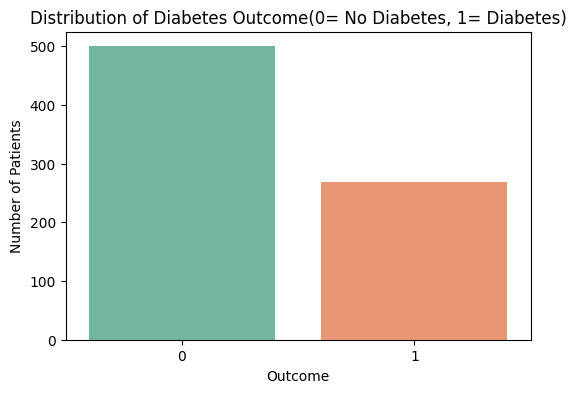

In [8]:
plt.figure(figsize =(6,4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Distribution of Diabetes Outcome(0= No Diabetes, 1= Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Number of Patients')
plt.show()

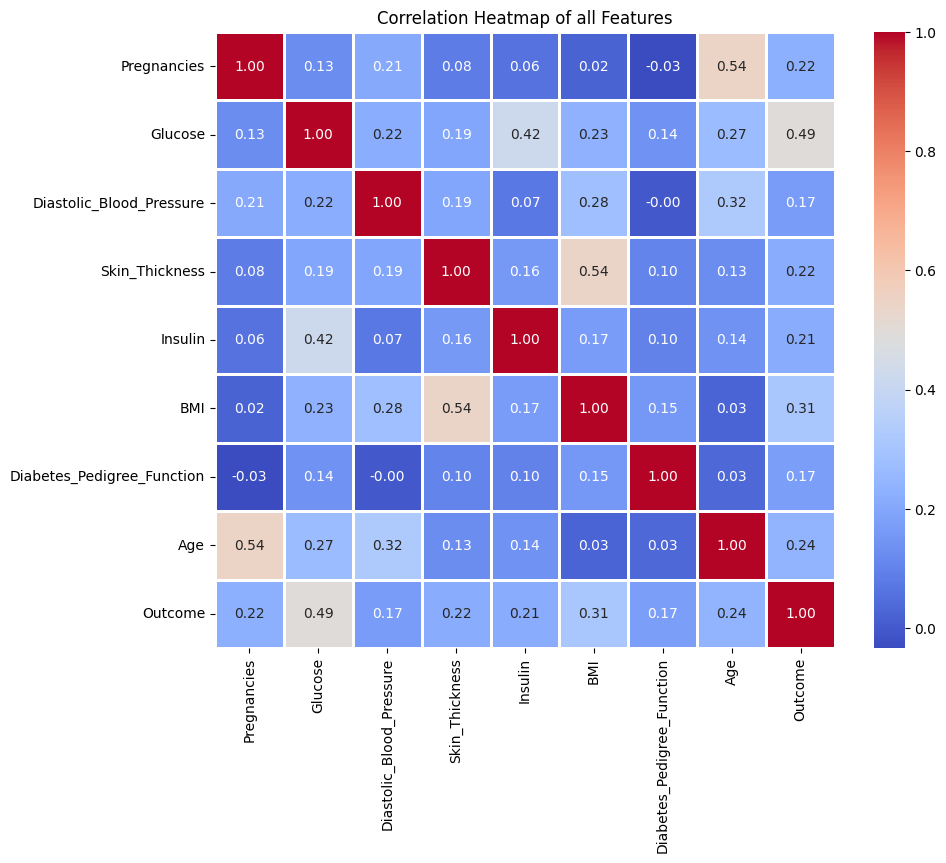

In [9]:
plt.figure(figsize=(10,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt = '0.2f', linewidths =1)
plt.title('Correlation Heatmap of all Features')
plt.show()

Text(0.5, 1.02, 'Pairplot of Top Features')

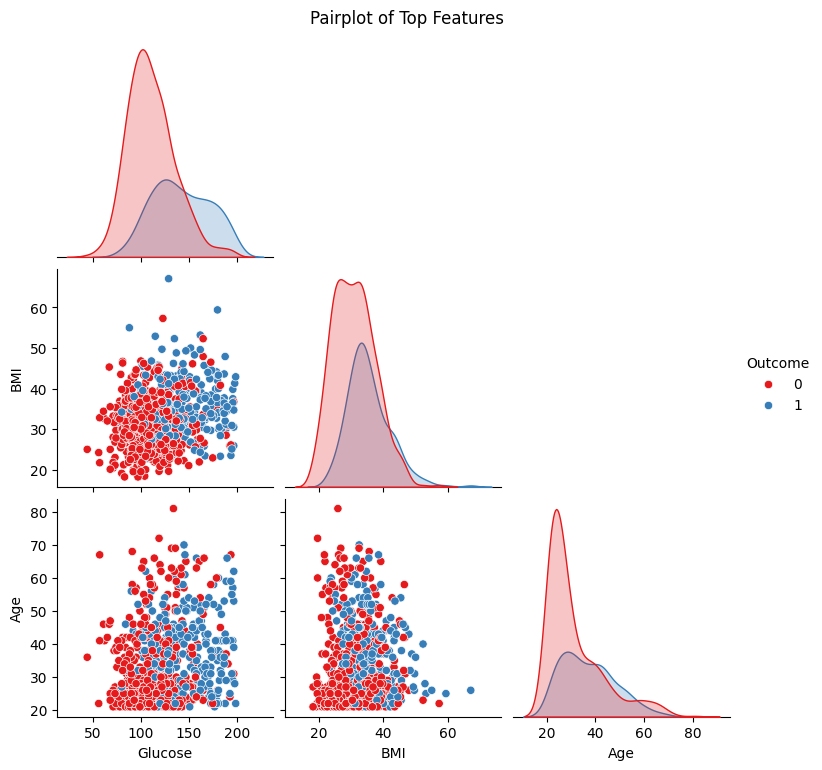

In [10]:
top_features = ['Glucose','BMI','Age','Outcome']
sns.pairplot(df[top_features], hue='Outcome', palette='Set1', corner='True')
plt.suptitle('Pairplot of Top Features', y=1.02)

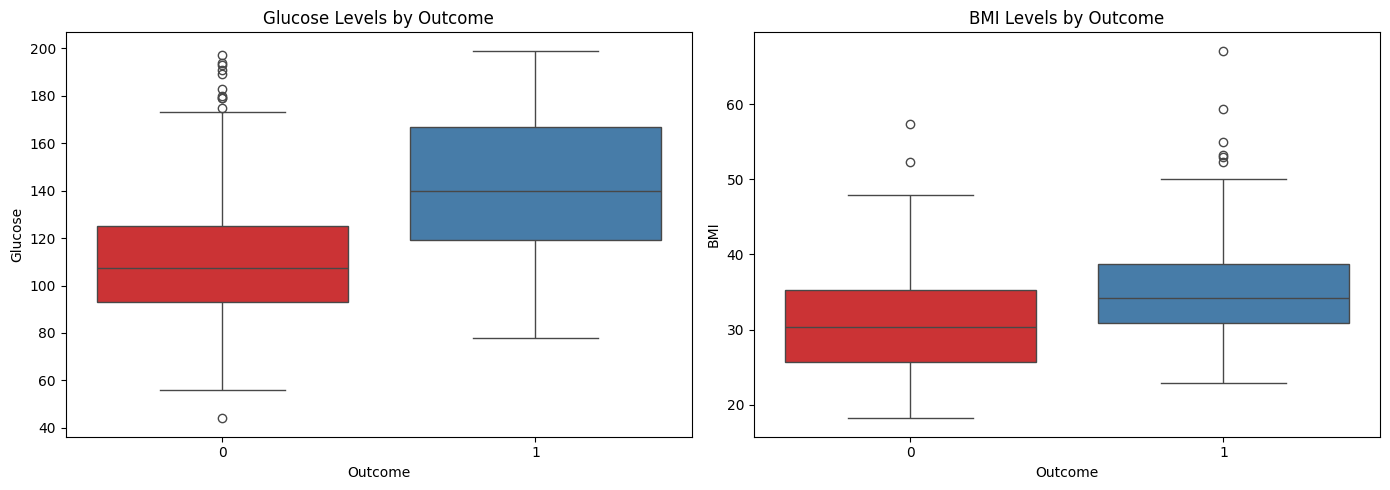

In [11]:
fig, axes= plt.subplots(1,2, figsize=(14,5))
sns.boxplot(x='Outcome',y='Glucose',hue='Outcome',data=df,palette='Set1',ax=axes[0],legend=False)
axes[0].set_title('Glucose Levels by Outcome')
sns.boxplot(x='Outcome',y='BMI',hue='Outcome',data=df,palette='Set1',ax=axes[1],legend=False)
axes[1].set_title('BMI Levels by Outcome')
plt.tight_layout()
plt.show()

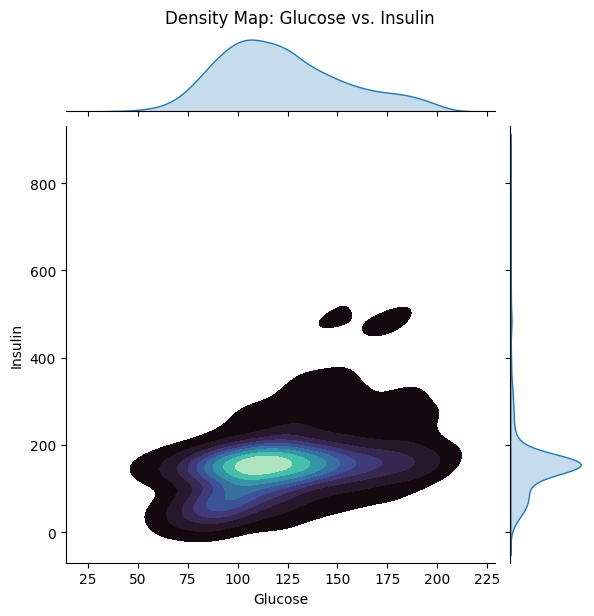

In [12]:
sns.jointplot(x='Glucose', y='Insulin', data=df, kind='kde', fill=True, cmap='mako')

plt.suptitle('Density Map: Glucose vs. Insulin', y=1.02)
plt.show()

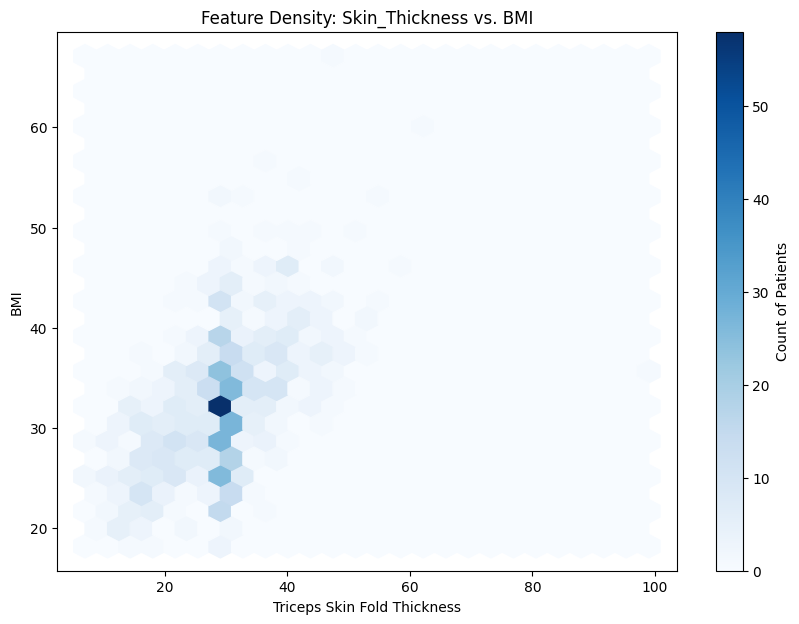

In [13]:
plt.figure(figsize=(10, 7))

plt.hexbin(df['Skin_Thickness'], df['BMI'], gridsize=25, cmap='Blues')

plt.title('Feature Density: Skin_Thickness vs. BMI')
plt.xlabel('Triceps Skin Fold Thickness')
plt.ylabel('BMI')

cb = plt.colorbar(label='Count of Patients')
plt.show()

# Data Preprocessing

In [15]:
x=df.drop('Outcome', axis=1)
y=df['Outcome']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)
print(f"Training features shape: {x_train.shape}")
print(f"Testing features shape: {x_test.shape}")

Training features shape: (614, 8)
Testing features shape: (154, 8)


# Model Training and Visual Evaluation


Evaluating: Logistic Regression
Accuracy: 0.7532

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



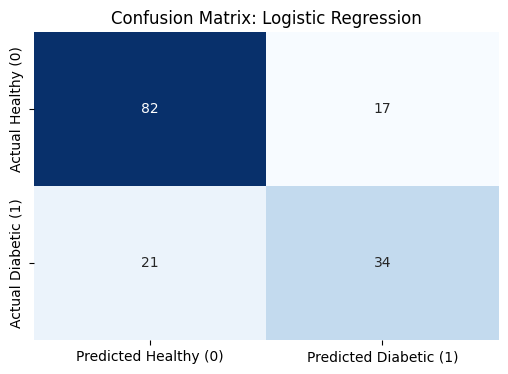


Evaluating: Random Forest
Accuracy: 0.7532

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



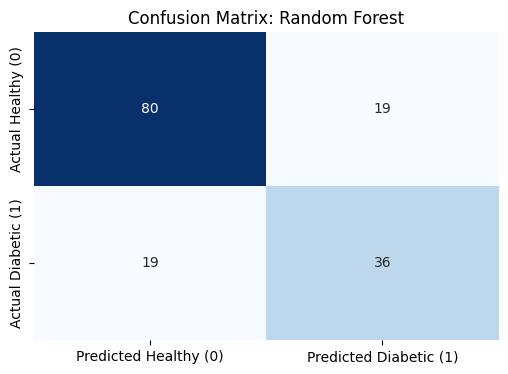


Evaluating: Gradient Boosting
Accuracy: 0.7338

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79        99
           1       0.61      0.69      0.65        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154



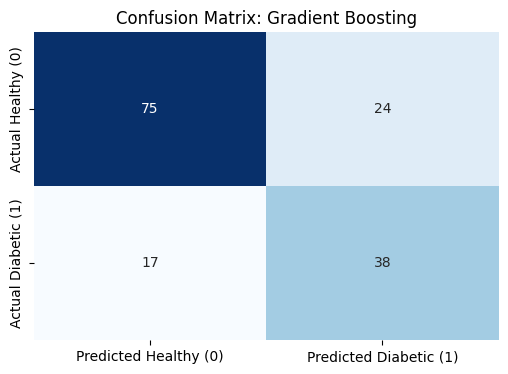

In [16]:
pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42))
    ]),

    "Gradient Boosting": Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(random_state=42))
    ])
}

for name, pipeline in pipelines.items():
    print(f"\n{'='*40}")
    print(f"Evaluating: {name}")
    print(f"{'='*40}")

    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Healthy (0)', 'Predicted Diabetic (1)'],
                yticklabels=['Actual Healthy (0)', 'Actual Diabetic (1)'])

    plt.title(f'Confusion Matrix: {name}')

    plt.show()

In [20]:
for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(x_test)

    recall = recall_score(y_test, y_pred, pos_label=1)

    print(f"{name} recall: {recall:.4f}  ({recall * 100:.1f}%)")

Logistic Regression recall: 0.6182  (61.8%)
Random Forest recall: 0.6545  (65.5%)
Gradient Boosting recall: 0.6909  (69.1%)


Extracting clinical feature importances from Gradient Boosting...


/tmp/ipykernel_2924/1338633500.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


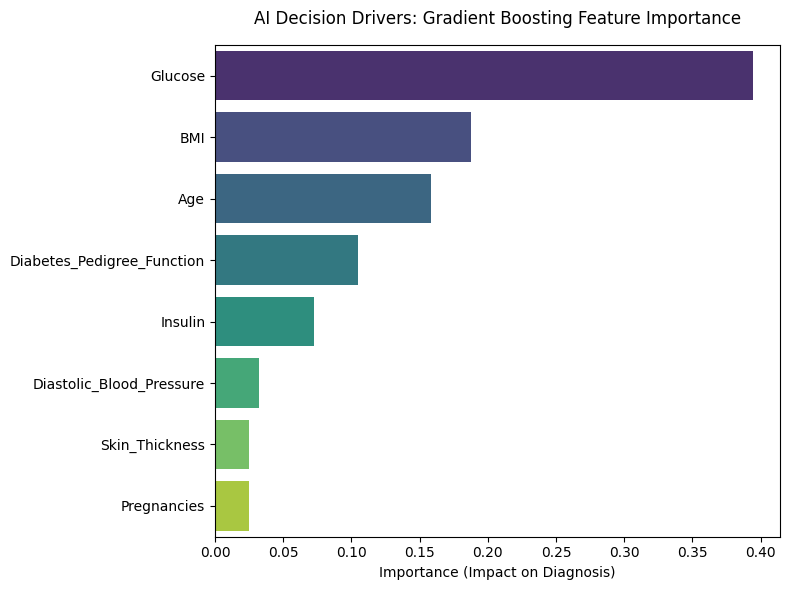


Exact Feature Weights:
Glucose: 39.4%
BMI: 18.8%
Age: 15.8%
Diabetes_Pedigree_Function: 10.5%
Insulin: 7.2%
Diastolic_Blood_Pressure: 3.2%
Skin_Thickness: 2.5%
Pregnancies: 2.5%


In [21]:
print("Extracting clinical feature importances from Gradient Boosting...")

winning_pipeline = pipelines["Gradient Boosting"]

trained_gb_model = winning_pipeline.named_steps['model']

importance_scores = trained_gb_model.feature_importances_
feature_names = x.columns

importance_df = pd.DataFrame({
    'Clinical Feature': feature_names,
    'Importance Weight': importance_scores
}).sort_values(by='Importance Weight', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    x='Importance Weight',
    y='Clinical Feature',
    data=importance_df,
    palette='viridis'
)

plt.title('AI Decision Drivers: Gradient Boosting Feature Importance', pad=15)
plt.xlabel('Importance (Impact on Diagnosis)')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("\nExact Feature Weights:")
for index, row in importance_df.iterrows():
    print(f"{row['Clinical Feature']}: {row['Importance Weight'] * 100:.1f}%")

In [23]:
import joblib
from google.colab import files

print("Packaging the Champion Model.")

champion_model = pipelines["Gradient Boosting"]

filename = 'diabetes_clinical_model.pkl'

joblib.dump(champion_model, filename)
print(f"Success! Model saved as: {filename}")

files.download(filename)

Packaging the Champion Model.
Success! Model saved as: diabetes_clinical_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>